makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


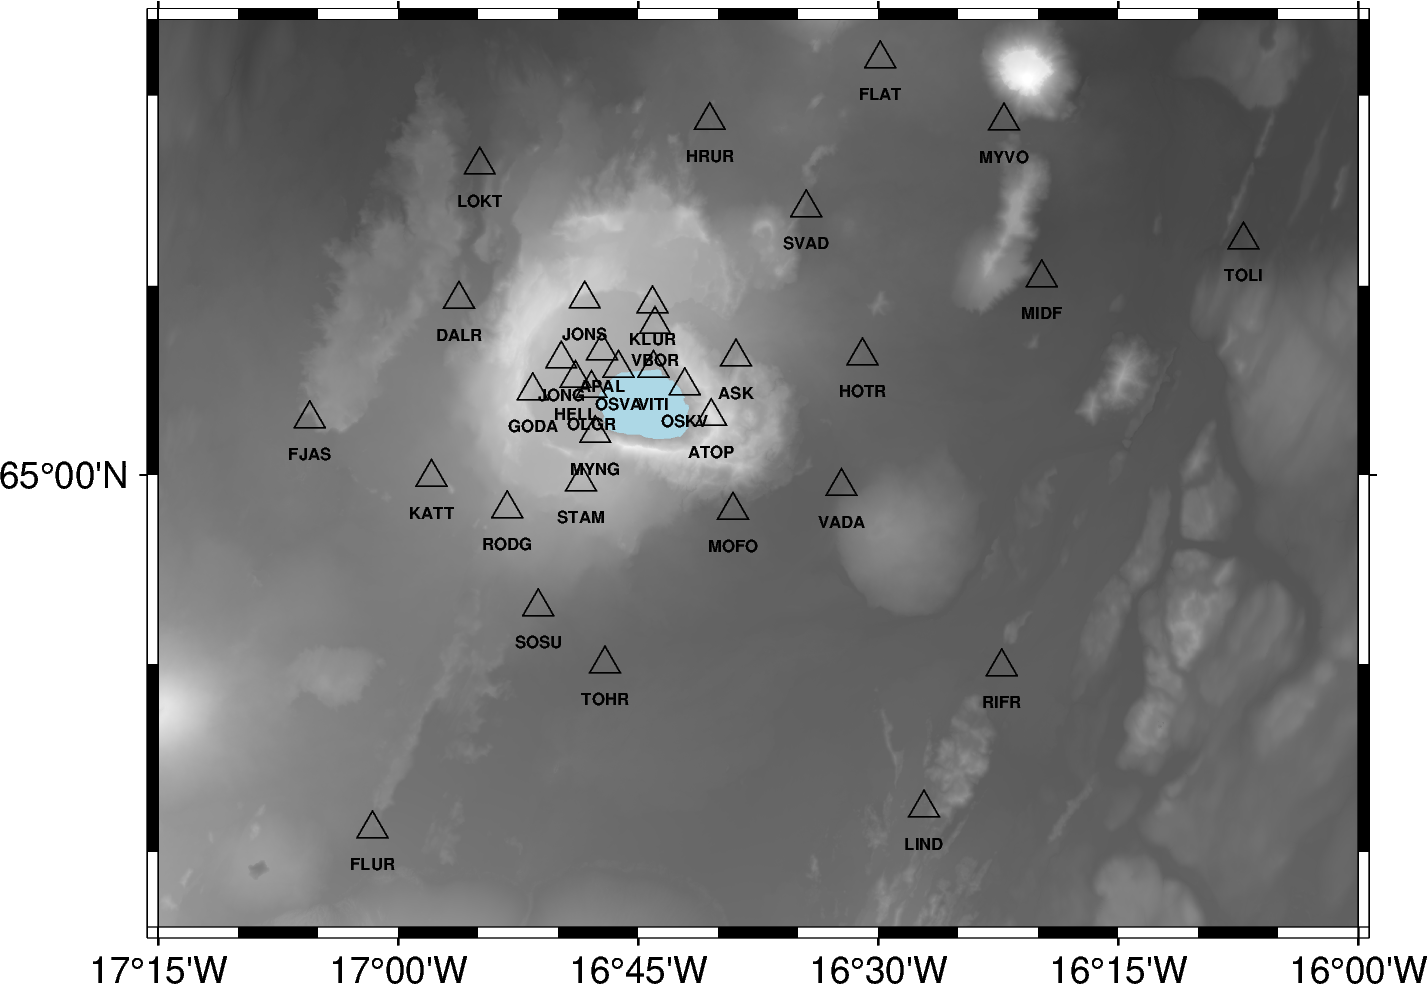

In [2]:
import pygmt
import pandas as pd
import numpy as np
import obspy
from obspy.core.inventory import read_inventory
import geopandas as gpd

minlon, maxlon = -17.25, -16
minlat, maxlat = 64.8, 65.2

stations1= pd.read_csv('/raid2/cg812/Stations_to_use.csv')
lake= gpd.read_file('/raid2/cg812/Askja_lake.geojson')





#stations= filtered1_df.iloc[:,0]
#CERT_stations= filtered2_df.iloc[:,0]
#combined= pd.concat([stations, CERT_stations], ignore_index= True)
#combined.to_csv('/raid2/cg812/Stations_to_use', index=False)

plotted_stations = pygmt.Figure()
topo_data= '/raid5/Iceland/data/IslandsDEM/IslandsDEMv0_10x10m_zmasl_isn2016_PROJECTED.grd'

plotted_stations = pygmt.Figure()
pygmt.makecpt(
    cmap='gray', series='100/1600',
    continuous=True
)

plotted_stations.grdimage(
    grid=topo_data, region= [minlon, maxlon, minlat, maxlat],
    projection='M4i',
    frame=True
    )


plotted_stations.plot(data= lake, fill= 'lightblue')



#plotted_stations.plot( x=x, y=y)

for _, row in stations1.iterrows():
    plotted_stations.plot(
        x=row.iloc[2],
        y=row.iloc[1], style="t0.3c")

# Add labels
for _, row in stations1.iterrows():
    plotted_stations.text(
        x=row.iloc[2],
        y=row.iloc[1],
        text=str(row.iloc[0]),  # Assumes name/ID is in first column
        font="4p,Helvetica-Bold,black",
        offset="0c/-0.3c"  # Adjust position of the label
    )

plotted_stations.show()
#plotted_stations.savefig('/raid2/cg812/Plotted_stations.pdf')


